# Week 2 Assignment - Classical Machine Learning Pipeline

## Objective

The main goal of this project is to predict Tesla vehicle deliveries by building an end-to-end machine learning pipeline. This includes data cleaning, exploratory data analysis, feature engineering, model training, evaluation, and comparing different models to find the best-performing solution.

Dataset:- Tesla Deliveries 2015 to 2025                                                                                  (1. Importing the libraries which are required for the project)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

2. Loading the dataset and displaying the top 5 data

In [28]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")


df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
# Analyzing the dataset to identify the target values and to make sure that the dataset is cleaned or not.

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


The dataset is all about Tesla deliveries, production units, pricing, vehicle specifications, region, model, source type, and charging infrastructure information. As the data has both numerical and categorical columns, preprocessing(Cleaning) is required before model training.

3. Data cleaning

In [33]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


In [34]:
# To drop out the duplicates 
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2640, 12)


Data cleaning is important because missing values and duplicate records can affect model performance. Checked for missing values and removed duplicates before moving to analysis and modeling.

4. Exploratory Data Analysis

Deliveries by Model

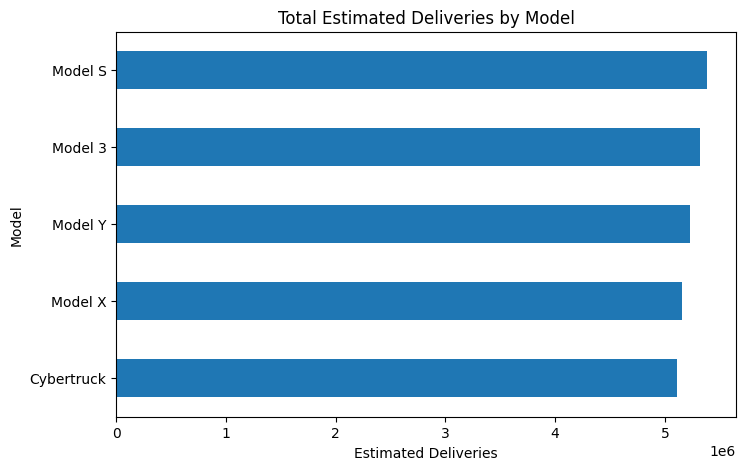

In [35]:
plt.figure(figsize=(8, 5))
df.groupby("Model")["Estimated_Deliveries"].sum().sort_values().plot(kind="barh")
plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Model")
plt.show()

Deliveries by Region

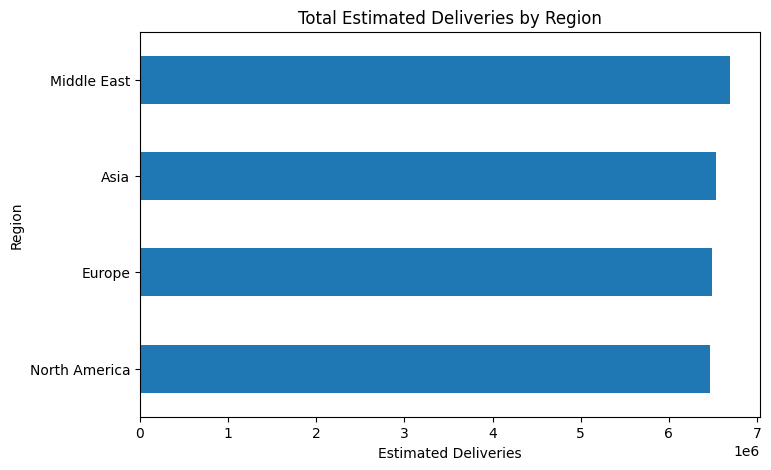

In [36]:
plt.figure(figsize=(8, 5))
df.groupby("Region")["Estimated_Deliveries"].sum().sort_values().plot(kind="barh")
plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Region")
plt.show()

Correlation Heatmap

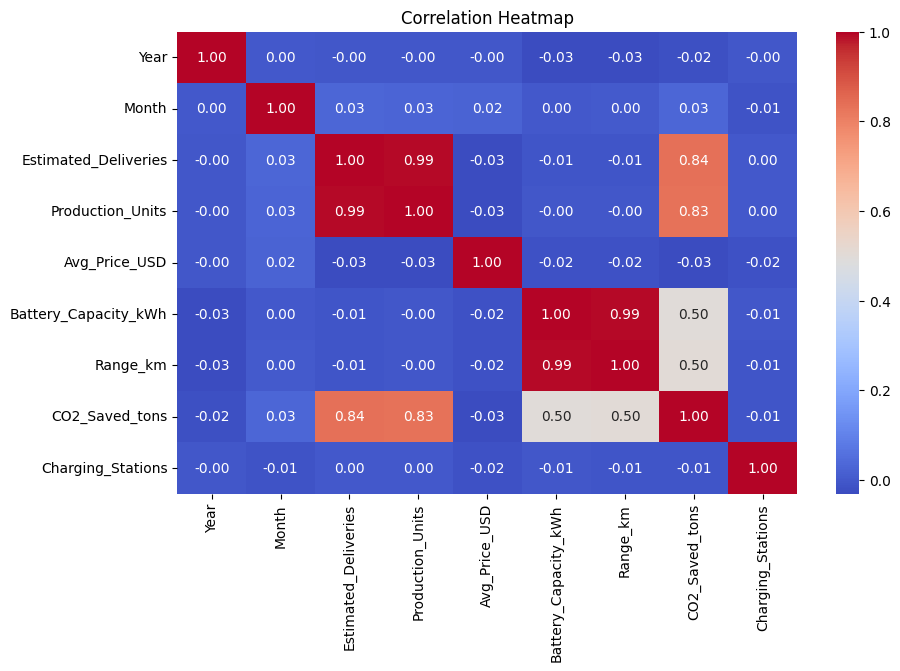

In [37]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Production vs Deliveries

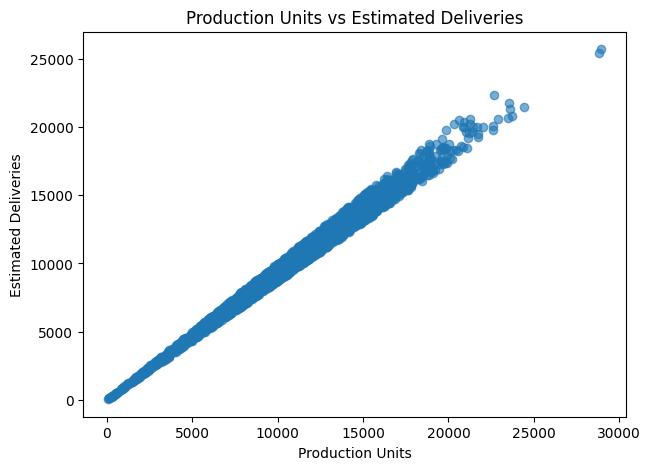

In [38]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Production_Units"], df["Estimated_Deliveries"], alpha=0.6)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

Time Trend

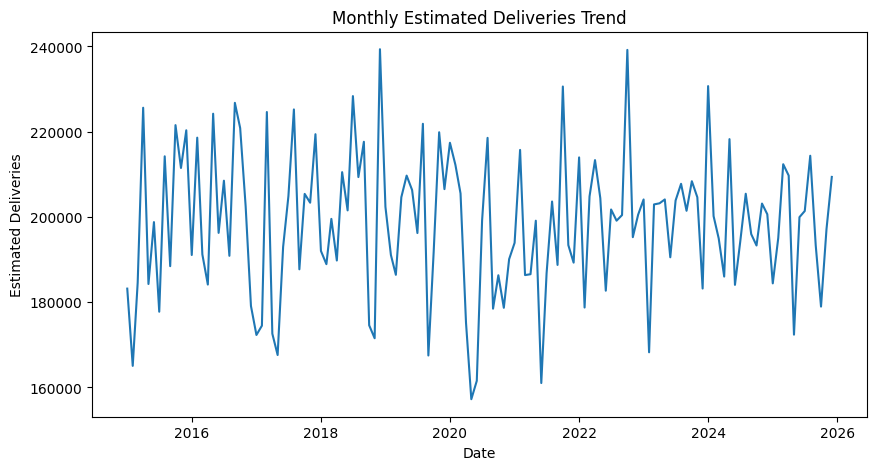

In [39]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")

monthly_deliveries = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_deliveries["Date"], monthly_deliveries["Estimated_Deliveries"])
plt.title("Monthly Estimated Deliveries Trend")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

Outlier Check

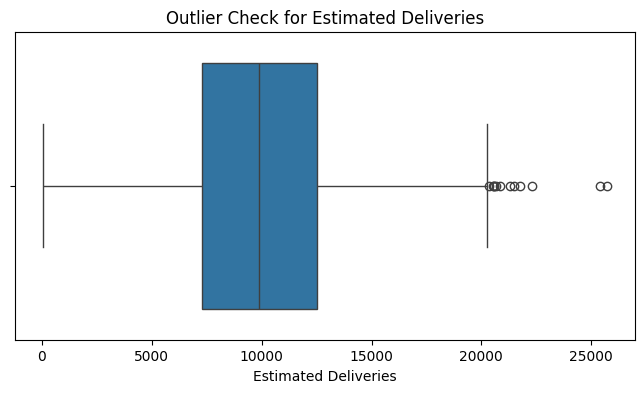

In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Estimated_Deliveries"])
plt.title("Outlier Check for Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.show()

EDA helped to understand the delivery patterns by model, region, and time. The correlation heatmap shows how numerical features are related, and the scatter plot confirms that production units have a strong relationship with estimated deliveries.

5. Encoding and Feature Engineering

In [41]:
df_model = df.copy()

encoder_region = LabelEncoder()
encoder_model = LabelEncoder()
encoder_source = LabelEncoder()

df_model["Region"] = encoder_region.fit_transform(df_model["Region"])
df_model["Model"] = encoder_model.fit_transform(df_model["Model"])
df_model["Source_Type"] = encoder_source.fit_transform(df_model["Source_Type"])

In [42]:
df_model = df_model.sort_values(["Year", "Month"]).reset_index(drop=True)

df_model["Deliveries_Lag1"] = df_model["Estimated_Deliveries"].shift(1)
df_model["Rolling_Mean_3"] = df_model["Estimated_Deliveries"].rolling(window=3).mean()

df_model["Deliveries_Lag1"] = df_model["Deliveries_Lag1"].fillna(df_model["Deliveries_Lag1"].mean())
df_model["Rolling_Mean_3"] = df_model["Rolling_Mean_3"].fillna(df_model["Rolling_Mean_3"].mean())

In [43]:
df_model["Quarter"] = ((df_model["Month"] - 1) // 3) + 1

df_model["Production_Delivery_Ratio"] = (
    df_model["Production_Units"] / df_model["Estimated_Deliveries"]
)

df_model["Price_per_Range"] = (
    df_model["Avg_Price_USD"] / df_model["Range_km"]
)

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model = df_model.fillna(df_model.mean(numeric_only=True))

display(df_model.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Deliveries_Lag1,Rolling_Mean_3,Quarter,Production_Delivery_Ratio,Price_per_Range
0,2015,1,2,4,10348,10835,85599.95,82,488,757.47,0,5991,2015-01-01,9921.649488,9921.864797,1,1.047062,175.409734
1,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,10348.000000,9921.864797,1,1.115619,162.303324
2,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,2,12301,2015-01-01,12446.000000,11209.666667,1,1.081957,87.659903
3,2015,1,3,3,8122,8343,62838.32,75,423,515.34,2,9297,2015-01-01,10835.000000,10467.666667,1,1.027210,148.553948
4,2015,1,2,2,13902,15423,94629.02,75,445,927.96,2,8666,2015-01-01,8122.000000,10953.000000,1,1.109409,212.649483


Encoded the categorical columns because machine learning models need numerical input. Also created lag and rolling mean features because previous delivery values can help predict future deliveries. Additional ratio-based features are added to capture useful relationships in the data.

6. Data Leakage

To avoid the data leakage, the dataset is sorted by time and split chronologically. This ensures that future records are not used while training the model, which gives best to evaluate the time-based data.

7. Train-Test Split of Data

In [44]:
target = "Estimated_Deliveries"

features = [
    "Year", "Month", "Quarter",
    "Region", "Model", "Source_Type",
    "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km",
    "CO2_Saved_tons", "Charging_Stations",
    "Deliveries_Lag1", "Rolling_Mean_3",
    "Production_Delivery_Ratio", "Price_per_Range"
]

X = df_model[features]
y = df_model[target]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2112, 16)
Testing data: (528, 16)


As here chronological split is used instead of random splitting because this dataset has a time-based structure. The first 80% of records are used for training and the latest 20% are used for testing.

8. Linear Regression Pipeline

In [47]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred =linear_pipeline.predict(X_test)

linear_mae =mean_absolute_error(y_test, linear_pred)
linear_rmse =np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 =r2_score(y_test, linear_pred)

print("Linear Regression Performance")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression Performance
MAE: 104.85942291198306
RMSE: 149.47772011086067
R²: 0.9983393006283722


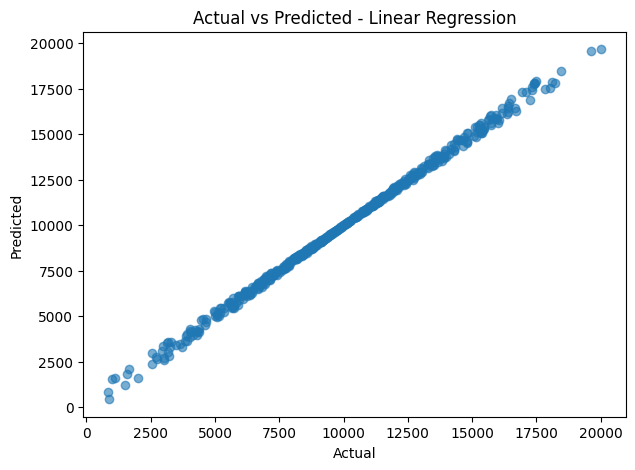

In [48]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, linear_pred, alpha=0.6)
plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Linear Regression is used as the baseline model. Because it helps to understand how well the features explain estimated deliveries using a simple linear relationship.

9. Cross Validation

In [49]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    linear_pipeline,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Per-fold R² scores:")
print(cv_scores)

print("Mean R²:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Per-fold R² scores:
[0.99853664 0.99826952 0.99844652 0.99836693 0.99854767]
Mean R²: 0.9984334552551273
Std Dev: 0.00010503614577325217


Cross-validation checks whether the model performs consistently across different data splits. A high mean R² with low standard deviation tells us that the model is stable.

10. Random Forest GridSearchCV

In [50]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.9978593725479866


In [51]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 63.39955302632178
RMSE: 96.63278770260511
R²: 0.9993059558343241


11. Feature Importance

In [52]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

display(importance_df.head(10))

,Feature,Importance
6,Production_Units,0.990500
14,Production_Delivery_Ratio,0.008286
13,Rolling_Mean_3,0.000245
10,CO2_Saved_tons,0.000171
15,Price_per_Range,0.000171
9,Range_km,0.000083
7,Avg_Price_USD,0.000081
12,Deliveries_Lag1,0.000078
1,Month,0.000076
0,Year,0.000070


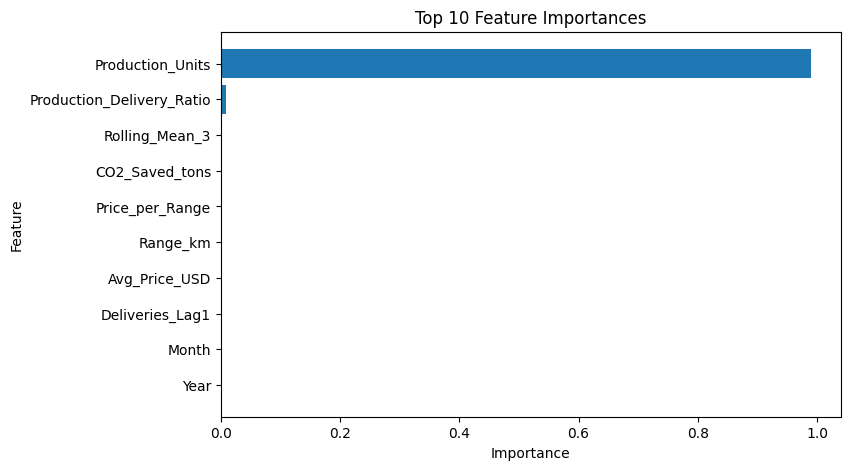

In [ ]:
# Showing the top 10 feature in bar chart 
plt.figure(figsize=(8, 5))
plt.barh(importance_df.head(10)["Feature"], importance_df.head(10)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance chart shows that **Production_Units** has the highest impact on predicting estimated deliveries. This is because the number of vehicles produced is directly related to the number of deliveries.

12. ADF Stationarity Test

In [53]:
adf_result = adfuller(df_model["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The series is stationary.")
else:
    print("Conclusion: The series is not stationary.")

ADF Statistic: -24.662112249181465
p-value: 0.0
Conclusion: The series is stationary.


The ADF test checks that whether a time series is stationary. If the p-value is less than 0.05, we reject the null hypothesis and consider the series stationary. If it is greater than 0.05, the series is not stationary.

14. Model Comparison Table

In [54]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R²": [linear_r2, rf_r2]
})

display(model_comparison)

,Model,MAE,RMSE,R²
0,Linear Regression,104.859423,149.477720,0.998339
1,Random Forest,63.399553,96.632788,0.999306


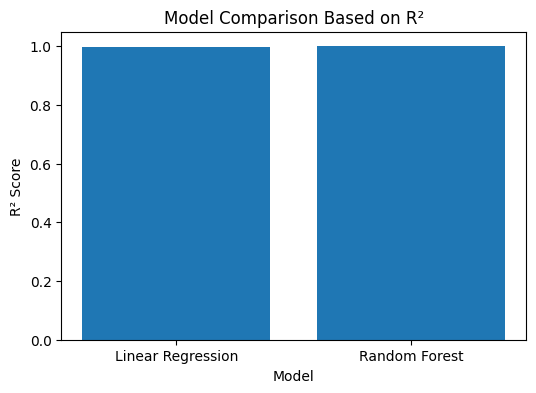

In [55]:
plt.figure(figsize=(6, 4))
plt.bar(model_comparison["Model"], model_comparison["R²"])
plt.title("Model Comparison Based on R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

The above comparison table shows the performance of Linear Regression and Random Forest using MAE, RMSE, and R². Random Forest is expected to perform better because it can learn non-linear relationships in the data as linear mainly works for numerical data.

15. Forecast Table for Top 20 test records

In [56]:
forecast_table = pd.DataFrame({
    "Actual": y_test.iloc[:20].values,
    "Predicted": rf_pred[:20]
})

forecast_table["Error"] = forecast_table["Actual"] - forecast_table["Predicted"]

forecast_table["Error %"] = (
    abs(forecast_table["Error"]) / forecast_table["Actual"]
) * 100

forecast_table["Error %"] = forecast_table["Error %"].round(2)

forecast_table

,Actual,Predicted,Error,Error %
0,9476,9412.864575,63.135425,0.67
1,8179,8177.082004,1.917996,0.02
2,14430,14674.382468,-244.382468,1.69
3,15912,15700.022340,211.977660,1.33
4,15077,15041.224320,35.775680,0.24
5,11280,11254.661648,25.338352,0.22
6,4070,4112.668170,-42.668170,1.05
7,11636,11641.698317,-5.698317,0.05
8,12540,12495.351283,44.648717,0.36
9,12717,12641.923319,75.076681,0.59


## Final Conclusion

In this assignment, How to built a complete machine learning pipeline using Tesla deliveries data. I explored the dataset, cleaned the data, performed exploratory data analysis, created time-based features, and trained different regression models to predict estimated deliveries.

Comparing multiple models helped me understand how model selection and feature engineering can improve prediction performance. I also learned the importance of chronological splitting, cross-validation, hyperparameter tuning, and avoiding data leakage while working with time-based data.

Overall, this assignment gave me practical experience in applying classical machine learning concepts to a real dataset and helped me understand how each step contributes to building a reliable prediction model.